In [7]:
import pandas as pd

# This will skip bad lines instead of crashing
df = pd.read_csv("data_raw.csv", low_memory=False, on_bad_lines='skip')

# Show first 5 rows
df.head()

,,,,,,,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LALACK,1005990,233847,40.808515,-73.921467,POINT (-73.921467 40.808515)
302692601,03/12/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,40,0,25-44,M,BLACK,1008067,236070.0,40.814611,-73.913956,POINT (-73.913956 40.814611)
303343948,03/21/2025,153,RAPE 3,104.0,RAPE,PL 1302507,F,K,78,0,25-44,M,WHITE HISPANIC,991330,187303.0,40.680786,-73.9744751162161,POINT (-73.9744751162161 40.6807856126343)
303620708,03/25/2025,263,"ARSON 2,3,4",114.0,ARSON,PL 1501500,F,K,69,71,25-44,M,WHITE,1014039,172089.0,40.638981,-73.892664,POINT (-73.892664 40.638981)
304075512,04/02/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,52,0,45-64,M,BLACK,1016352,255400.0,40.867640,-73.883934,POINT (-73.883934 40.86764)
304144535,04/03/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,M,32,0,45-64,M,BLACK,1001811,239897.0,40.825129,-73.936548,POINT (-73.936548 40.825129)


In [9]:
bad_rows = pd.read_csv("data_raw.csv", low_memory=False, on_bad_lines='warn')

C:\Users\AMD 10\AppData\Local\Temp\ipykernel_24132\3312355613.py:1: ParserWarning: Skipping line 8: expected 19 fields, saw 27

  bad_rows = pd.read_csv("data_raw.csv", low_memory=False, on_bad_lines='warn')


In [10]:
# Replace '(null)' with actual NaN
df = df.replace("(null)", pd.NA)

# Check missing values
df.isna().sum()

ARREST_KEY                        1474
ARREST_DATE                          0
PD_CD                                0
PD_DESC                              0
KY_CD                           147236
OFNS_DESC                       147236
LALACK                               0
1005990                              0
233847                               0
40.808515                            0
-73.921467                           0
POINT (-73.921467 40.808515)         1
dtype: int64

In [11]:
print(df.head(10).T)  # Transpose to see columns easily

                                                 302692601  \
                                                03/12/2025   
                                                       105   
                                         STRANGULATION 1ST   
                                                     106.0   
                                            FELONY ASSAULT   
                                                PL 1211200   
ARREST_KEY                                               F   
ARREST_DATE                                              B   
PD_CD                                                   40   
PD_DESC                                                  0   
KY_CD                                                25-44   
OFNS_DESC                                                M   
LALACK                                               BLACK   
1005990                                            1008067   
233847                                            236070.0   
40.80851

In [15]:
columns = ["ARREST_KEY","ARREST_DATE","PD_CD","PD_DESC","KY_CD","OFNS_DESC",
           "LAW_CODE","LAW_CAT_CD","ARREST_BORO","ARREST_PRECINCT","JURISDICTION_CODE",
           "AGE_GROUP","PERP_SEX","PERP_RACE","X_COORD_CD","Y_COORD_CD","Latitude","Longitude","Location"]
df = pd.read_csv("data_raw.csv", names=columns, header=0, low_memory=False, on_bad_lines='skip')
print(df)

        ARREST_KEY ARREST_DATE  PD_CD                         PD_DESC  KY_CD  \
0        302692601  03/12/2025    105               STRANGULATION 1ST  106.0   
1        303343948  03/21/2025    153                          RAPE 3  104.0   
2        303620708  03/25/2025    263                     ARSON 2,3,4  114.0   
3        304075512  04/02/2025    105               STRANGULATION 1ST  106.0   
4        304144535  04/03/2025    105               STRANGULATION 1ST  106.0   
...            ...         ...    ...                             ...    ...   
278947   318159497  12/30/2025    339  LARCENY,PETIT FROM OPEN AREAS,  341.0   
278948   318206208  12/31/2025    101                       ASSAULT 3  344.0   
278949   318144122  12/30/2025    101                       ASSAULT 3  344.0   
278950   318209021  12/31/2025    779  PUBLIC ADMINISTRATION,UNCLASSI  126.0   
278951   318207879  12/31/2025    922  TRAFFIC,UNCLASSIFIED MISDEMEAN  348.0   

                           OFNS_DESC   

In [17]:
df['ARREST_DATE'] = pd.to_datetime(df['ARREST_DATE'], errors='coerce', format='%m/%d/%Y')
numeric_cols = ['PD_CD','KY_CD','X_COORD_CD','Y_COORD_CD','Latitude','Longitude']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [18]:
categorical_cols = ['PERP_SEX','PERP_RACE','OFNS_DESC','ARREST_BORO',
                    'LAW_CAT_CD','ARREST_PRECINCT','JURISDICTION_CODE','AGE_GROUP']
for col in categorical_cols:
    df[col] = df[col].astype('string')

In [21]:

# Replace '(null)' and empty strings with NaN
df = df.replace({"(null)": pd.NA, "": pd.NA})

# Check the first 5 rows to see the changes
print(df.head())

   ARREST_KEY ARREST_DATE  PD_CD            PD_DESC  KY_CD       OFNS_DESC  \
0   302692601  2025-03-12    105  STRANGULATION 1ST  106.0  FELONY ASSAULT   
1   303343948  2025-03-21    153             RAPE 3  104.0            RAPE   
2   303620708  2025-03-25    263        ARSON 2,3,4  114.0           ARSON   
3   304075512  2025-04-02    105  STRANGULATION 1ST  106.0  FELONY ASSAULT   
4   304144535  2025-04-03    105  STRANGULATION 1ST  106.0  FELONY ASSAULT   

     LAW_CODE LAW_CAT_CD ARREST_BORO ARREST_PRECINCT JURISDICTION_CODE  \
0  PL 1211200          F           B              40                 0   
1  PL 1302507          F           K              78                 0   
2  PL 1501500          F           K              69                71   
3  PL 1211200          F           B              52                 0   
4  PL 1211200          F           M              32                 0   

  AGE_GROUP PERP_SEX       PERP_RACE  X_COORD_CD  Y_COORD_CD   Latitude  \
0     25-44

In [22]:
print(df.isna().sum())

ARREST_KEY                0
ARREST_DATE               0
PD_CD                     0
PD_DESC                  23
KY_CD                    23
OFNS_DESC                23
LAW_CODE                  0
LAW_CAT_CD             1474
ARREST_BORO               0
ARREST_PRECINCT           0
JURISDICTION_CODE         0
AGE_GROUP            147236
PERP_SEX             147236
PERP_RACE                 0
X_COORD_CD                0
Y_COORD_CD                0
Latitude                  0
Longitude                 1
Location                  1
dtype: int64


In [23]:
# Fill minor missing values
df['PD_DESC'] = df['PD_DESC'].fillna("Unknown")
df['KY_CD'] = df['KY_CD'].fillna(0)          # Use 0 for missing numeric codes
df['LAW_CAT_CD'] = df['LAW_CAT_CD'].fillna("Unknown")

# Preview changes
print("Step 1: Fill minor missing values")
print(df[['PD_DESC','KY_CD','LAW_CAT_CD']].head(10))
print(df[['PD_DESC','KY_CD','LAW_CAT_CD']].isna().sum(), "\n")

Step 1: Fill minor missing values
             PD_DESC  KY_CD LAW_CAT_CD
0  STRANGULATION 1ST  106.0          F
1             RAPE 3  104.0          F
2        ARSON 2,3,4  114.0          F
3  STRANGULATION 1ST  106.0          F
4  STRANGULATION 1ST  106.0          F
5             RAPE 1  104.0          F
6  STRANGULATION 1ST  106.0          F
7  STRANGULATION 1ST  106.0          F
8             RAPE 1  104.0          F
9             RAPE 3  104.0          F
PD_DESC       0
KY_CD         0
LAW_CAT_CD    0
dtype: int64 



In [24]:
df = df.dropna(subset=['AGE_GROUP','PERP_SEX'])

# Preview
print("Step 2: Drop rows missing AGE_GROUP or PERP_SEX")
print(df[['AGE_GROUP','PERP_SEX']].head(10))
print(df[['AGE_GROUP','PERP_SEX']].isna().sum(), "\n")

Step 2: Drop rows missing AGE_GROUP or PERP_SEX
   AGE_GROUP PERP_SEX
0      25-44        M
1      25-44        M
2      25-44        M
3      45-64        M
4      45-64        M
6      25-44        F
7      25-44        M
8      25-44        M
10     25-44        M
11     45-64        M
AGE_GROUP    0
PERP_SEX     0
dtype: int64 



In [25]:
df = df.drop_duplicates(subset='ARREST_KEY').reset_index(drop=True)

# Preview
print("Step 3: Drop duplicates and reset index")
print(df.head())
print(f"Total rows after cleaning: {len(df)}\n")

Step 3: Drop duplicates and reset index
   ARREST_KEY ARREST_DATE  PD_CD            PD_DESC  KY_CD       OFNS_DESC  \
0   302692601  2025-03-12    105  STRANGULATION 1ST  106.0  FELONY ASSAULT   
1   303343948  2025-03-21    153             RAPE 3  104.0            RAPE   
2   303620708  2025-03-25    263        ARSON 2,3,4  114.0           ARSON   
3   304075512  2025-04-02    105  STRANGULATION 1ST  106.0  FELONY ASSAULT   
4   304144535  2025-04-03    105  STRANGULATION 1ST  106.0  FELONY ASSAULT   

     LAW_CODE LAW_CAT_CD ARREST_BORO ARREST_PRECINCT JURISDICTION_CODE  \
0  PL 1211200          F           B              40                 0   
1  PL 1302507          F           K              78                 0   
2  PL 1501500          F           K              69                71   
3  PL 1211200          F           B              52                 0   
4  PL 1211200          F           M              32                 0   

  AGE_GROUP PERP_SEX       PERP_RACE  X_COORD_

In [26]:
print("Step 4: Final dataset info")
print(df.info())
print(df.isna().sum())

Step 4: Final dataset info
<class 'pandas.DataFrame'>
RangeIndex: 131716 entries, 0 to 131715
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ARREST_KEY         131716 non-null  int64         
 1   ARREST_DATE        131716 non-null  datetime64[us]
 2   PD_CD              131716 non-null  int64         
 3   PD_DESC            131716 non-null  str           
 4   KY_CD              131716 non-null  float64       
 5   OFNS_DESC          131704 non-null  string        
 6   LAW_CODE           131716 non-null  str           
 7   LAW_CAT_CD         131716 non-null  string        
 8   ARREST_BORO        131716 non-null  string        
 9   ARREST_PRECINCT    131716 non-null  string        
 10  JURISDICTION_CODE  131716 non-null  string        
 11  AGE_GROUP          131716 non-null  string        
 12  PERP_SEX           131716 non-null  string        
 13  PERP_RACE          131716 no

In [27]:
df['OFNS_DESC'] = df['OFNS_DESC'].fillna("Unknown")

In [28]:
df = df.dropna(subset=['Longitude','Location'])

In [29]:
print("Step 5: Final dataset check")
print(df.info())
print(df.isna().sum())
print(f"Total rows after final cleaning: {len(df)}")

Step 5: Final dataset check
<class 'pandas.DataFrame'>
Index: 131715 entries, 0 to 131715
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ARREST_KEY         131715 non-null  int64         
 1   ARREST_DATE        131715 non-null  datetime64[us]
 2   PD_CD              131715 non-null  int64         
 3   PD_DESC            131715 non-null  str           
 4   KY_CD              131715 non-null  float64       
 5   OFNS_DESC          131715 non-null  string        
 6   LAW_CODE           131715 non-null  str           
 7   LAW_CAT_CD         131715 non-null  string        
 8   ARREST_BORO        131715 non-null  string        
 9   ARREST_PRECINCT    131715 non-null  string        
 10  JURISDICTION_CODE  131715 non-null  string        
 11  AGE_GROUP          131715 non-null  string        
 12  PERP_SEX           131715 non-null  string        
 13  PERP_RACE          131715 non-nu

In [30]:
df.to_csv("data_cleaned.csv", index=False)

PART2 VIGUALIZATION

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

# Optional: improve plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

C:\Users\AMD 10\AppData\Local\Temp\ipykernel_24132\948154219.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=boro_counts.index, y=boro_counts.values, palette="viridis")


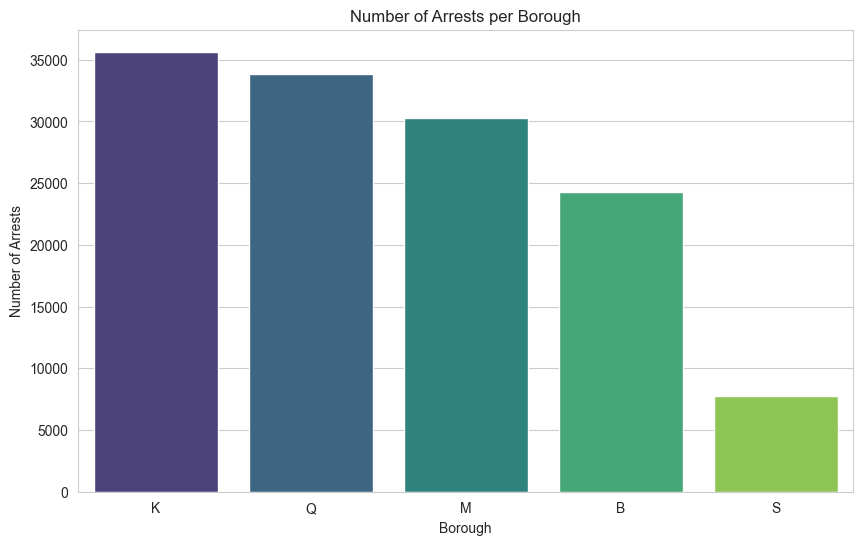

In [39]:
# Count of arrests per borough
boro_counts = df['ARREST_BORO'].value_counts()

# Bar plot
plt.figure()
sns.barplot(x=boro_counts.index, y=boro_counts.values, palette="viridis")
plt.title("Number of Arrests per Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Arrests")
plt.show()

C:\Users\AMD 10\AppData\Local\Temp\ipykernel_24132\1336795286.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crimes.values, y=top_crimes.index, palette="magma")


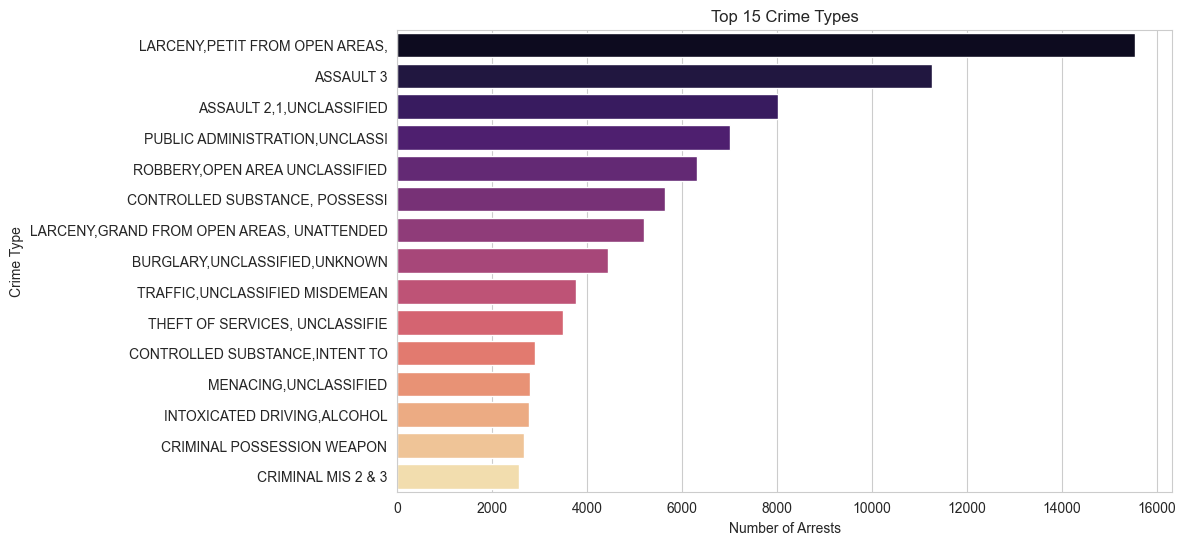

In [40]:
# Top 15 most frequent crime types
top_crimes = df['PD_DESC'].value_counts().head(15)

plt.figure()
sns.barplot(x=top_crimes.values, y=top_crimes.index, palette="magma")
plt.title("Top 15 Crime Types")
plt.xlabel("Number of Arrests")
plt.ylabel("Crime Type")
plt.show()

C:\Users\AMD 10\AppData\Local\Temp\ipykernel_24132\920878349.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=race_counts.index, y=race_counts.values, palette="coolwarm")


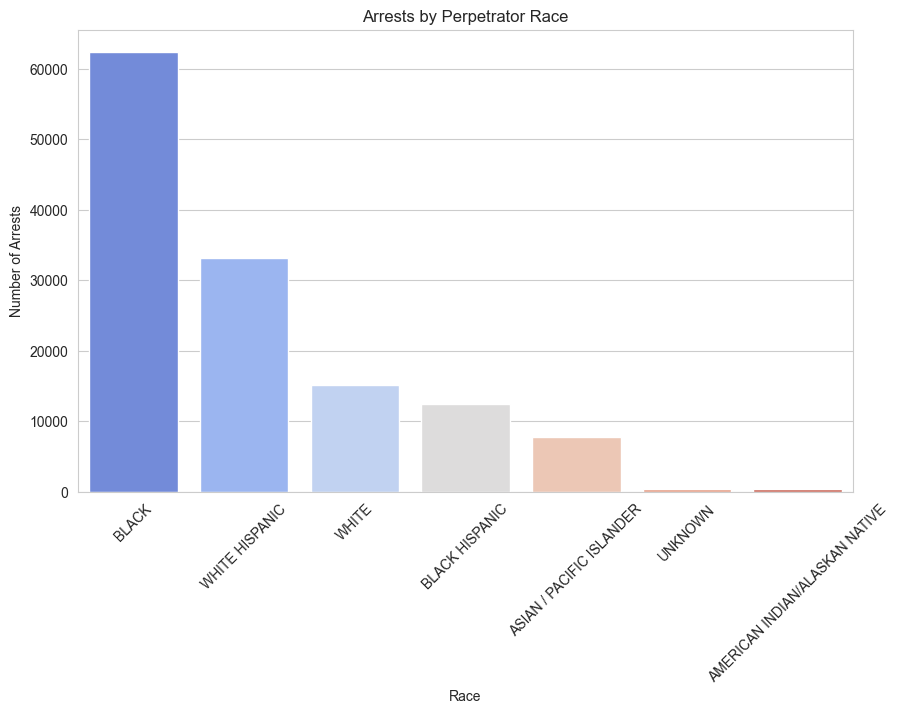

In [41]:
race_counts = df['PERP_RACE'].value_counts()

plt.figure()
sns.barplot(x=race_counts.index, y=race_counts.values, palette="coolwarm")
plt.title("Arrests by Perpetrator Race")
plt.xlabel("Race")
plt.ylabel("Number of Arrests")
plt.xticks(rotation=45)
plt.show()

C:\Users\AMD 10\AppData\Local\Temp\ipykernel_18520\201539427.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=boro_counts.index, y=boro_counts.values, palette="viridis")


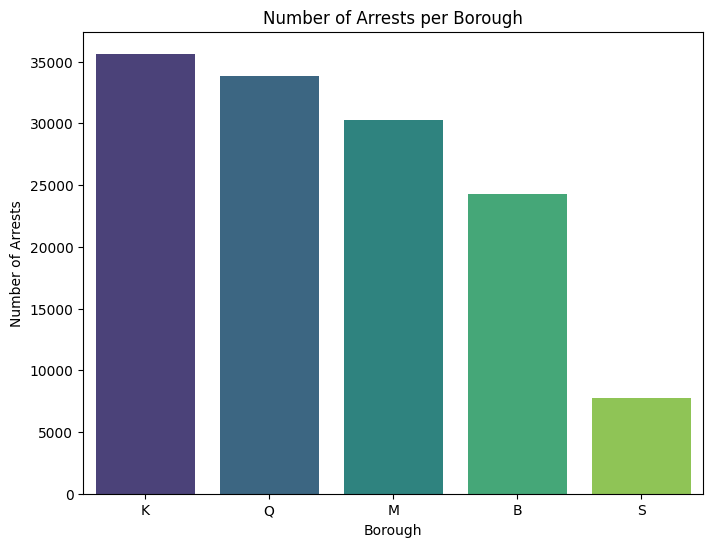

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count arrests per borough
boro_counts = df['ARREST_BORO'].value_counts()

# Create bar plot
plt.figure(figsize=(8,6))
sns.barplot(x=boro_counts.index, y=boro_counts.values, palette="viridis")
plt.title("Number of Arrests per Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Arrests")

# Save as PNG
plt.savefig("summary_plot.png", dpi=300, bbox_inches='tight')  # dpi=300 for high quality
plt.show()

In [5]:
# visualize.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import webbrowser

# ---------------------------
# Load the cleaned dataset
# ---------------------------
df = pd.read_csv("data_cleaned.csv", parse_dates=['ARREST_DATE'])

sns.set_style("whitegrid")

# ---------------------------
# 1. Arrests per Borough
# ---------------------------
boro_counts = df['ARREST_BORO'].value_counts()
plt.figure(figsize=(8,6))
sns.barplot(x=boro_counts.index, y=boro_counts.values, palette="viridis")
plt.title("Number of Arrests per Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Arrests")
plt.savefig("summary_plot.png", dpi=300, bbox_inches='tight')  # Save PNG
plt.close()  # Close figure to avoid overlap

# ---------------------------
# 2. Top 15 Crime Types
# ---------------------------
top_crimes = df['PD_DESC'].value_counts().head(15)
plt.figure(figsize=(10,7))
sns.barplot(x=top_crimes.values, y=top_crimes.index, palette="magma")
plt.title("Top 15 Crime Types")
plt.xlabel("Number of Arrests")
plt.ylabel("Crime Type")
plt.savefig("crime_plot.png", dpi=300, bbox_inches='tight')
plt.close()

# ---------------------------
# 3. Arrests by Perpetrator Race
# ---------------------------
race_counts = df['PERP_RACE'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=race_counts.index, y=race_counts.values, palette="coolwarm")
plt.title("Arrests by Perpetrator Race")
plt.xlabel("Race")
plt.ylabel("Number of Arrests")
plt.xticks(rotation=45)
plt.savefig("race_plot.png", dpi=300, bbox_inches='tight')
plt.close()

# ---------------------------
# 4. Interactive NYC Arrest Map (Folium)
# ---------------------------
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11)
for idx, row in df.sample(1000, random_state=42).iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=2,
        color='red',
        fill=True,
        fill_opacity=0.6
    ).add_to(nyc_map)

nyc_map.save("nyc_arrests_map.html")
webbrowser.open("nyc_arrests_map.html")

# ---------------------------
# 5. Heatmap of Arrests (Folium)
# ---------------------------
heat_data = df[['Latitude','Longitude']].sample(5000, random_state=42).values.tolist()
heatmap_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11)
HeatMap(heat_data, radius=10).add_to(heatmap_map)
heatmap_map.save("nyc_arrests_heatmap.html")
webbrowser.open("nyc_arrests_heatmap.html")

print("All plots saved as PNG and maps saved as HTML.")

C:\Users\AMD 10\AppData\Local\Temp\ipykernel_18520\3264862128.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=boro_counts.index, y=boro_counts.values, palette="viridis")
C:\Users\AMD 10\AppData\Local\Temp\ipykernel_18520\3264862128.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crimes.values, y=top_crimes.index, palette="magma")
C:\Users\AMD 10\AppData\Local\Temp\ipykernel_18520\3264862128.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=race_counts.index, y=race_counts.values, palette="coolwarm")


All plots saved as PNG and maps saved as HTML.


MEANINGFUL INSIGHTS

In [3]:
# analytics.py
import pandas as pd

# Load your cleaned dataset
df = pd.read_csv("data_cleaned.csv", parse_dates=['ARREST_DATE'])

# ----- Insight 1: Most common crime type -----
top_crime = df['PD_DESC'].value_counts().idxmax()
top_crime_count = df['PD_DESC'].value_counts().max()
insight1 = f"The most common crime in the dataset is '{top_crime}' with {top_crime_count} arrests."

# Save Insight 1
with open("insight1.txt", "w") as f:
    f.write(insight1)

# ----- Insight 2: Borough with the highest number of arrests -----
top_boro = df['ARREST_BORO'].value_counts().idxmax()
top_boro_count = df['ARREST_BORO'].value_counts().max()
insight2 = f"The borough with the highest number of arrests is '{top_boro}' with {top_boro_count} arrests."

# Save Insight 2
with open("insight2.txt", "w") as f:
    f.write(insight2)

# ----- Insight 3: Most common race among arrestees -----
top_race = df['PERP_RACE'].value_counts().idxmax()
top_race_count = df['PERP_RACE'].value_counts().max()
insight3 = f"The most common race among arrestees is '{top_race}' with {top_race_count} arrests."

# Save Insight 3
with open("insight3.txt", "w") as f:
    f.write(insight3)

print("Analytics complete: 3 insights saved as insight1.txt, insight2.txt, insight3.txt")

Analytics complete: 3 insights saved as insight1.txt, insight2.txt, insight3.txt


CLUSTERING

In [10]:
# cluster.py
import pandas as pd
from sklearn.cluster import KMeans
import numpy as np


# Load cleaned dataset

df = pd.read_csv("data_cleaned.csv", parse_dates=['ARREST_DATE'])


# Step 1: Prepare subset of features for clustering

cluster_features = df[['Latitude', 'Longitude', 'X_COORD_CD', 'Y_COORD_CD']].copy()

# Optional: scale features (K-Means benefits from scaling)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cluster_features_scaled = scaler.fit_transform(cluster_features)


# Step 2: Apply K-Means clustering


k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(cluster_features_scaled)

# Count samples per cluster

cluster_counts = df['Cluster'].value_counts().sort_index()

# Save to clusters.txt
with open("clusters.txt", "w") as f:
    for cluster_id, count in cluster_counts.items():
        f.write(f"Cluster {cluster_id}: {count} samples\n")

print("Clustering complete! Cluster counts saved to clusters.txt")

ModuleNotFoundError: No module named 'sklearn'